# Feature Selection GAS

In [1]:
stock_code = "GAS"

In [2]:
stock_code = str.lower(stock_code)

## Import libraries

In [3]:
import os
import sys
import pandas as pd


# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from feature_selector.feature_selector import (
    FeatureSelector,
)
from utils.constants import *
from utils.enums import *
from utils.utils import cast_columns_to_float
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from matplotlib.pylab import ceil

## Initialize the Logger

In [4]:
my_logger = Logger(
    file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/{stock_code}_feature_selection"
)

## List all FeatureSelectorType

In [5]:
print([member.name for member in FeatureSelectorType])

['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']


## Initialize the Database Driver

In [6]:
database_driver = PostgreSQLDriver(logger=my_logger)

connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

database_driver.connect(connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

## Parameters

In [7]:
output_column_name = "close"

In [8]:
train_ratio = DEFAULT_TRAIN_RATIO
train_window_size = DEFAULT_TRAIN_WINDOW_SIZE
validation_window_size = DEFAULT_VALIDATION_WINDOW_SIZE
test_window_size = DEFAULT_TEST_WINDOW_SIZE

## Load data

In [9]:
df = pd.read_csv(f"../../unified_dataframe/unified_{stock_code}.csv")

In [10]:
df

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2012-05-21,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,...,0,3,1,2,5.000000e-01,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,2012-05-22,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,...,0,4,1,2,5.000000e-01,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,2012-05-23,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,...,0,4,1,2,5.000000e-01,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,2012-05-24,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,...,0,4,1,2,5.000000e-01,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,2012-05-25,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,...,0,4,1,2,5.000000e-01,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0,3,1,3,1.224647e-16,-1.000000,-0.433884,-0.900969,0.196673,-0.980469
3265,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0,4,1,3,1.224647e-16,-1.000000,0.000000,1.000000,0.145799,-0.989314
3266,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0,4,1,3,1.224647e-16,-1.000000,0.974928,-0.222521,0.111659,-0.993747
3267,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0,4,1,3,1.224647e-16,-1.000000,0.433884,-0.900969,0.094537,-0.995521


In [11]:
def _find_split_index(
    dataframe: pd.DataFrame,
    train_window_size: int,
    validation_window_size: int,
    test_window_size: int,
    train_ratio: float,
) -> int:
    """
    Determine the index to split the dataframe into training and testing portions
    for time series forecasting with explicit validation and test windows.

    Rules:
    1. Split based on `train_ratio`.
    2. Ensure there's enough data left for both validation and test windows.
    3. Ensure the split index aligns cleanly with test window size for consistency.
    """

    # --- Sort chronologically if 'date' column exists ---
    if "date" in dataframe.columns:
        dataframe = dataframe.sort_values("date").reset_index(drop=True)
    else:
        dataframe = dataframe.reset_index(drop=True)

    total_len = len(dataframe)
    min_required = train_window_size + validation_window_size + test_window_size

    if total_len <= min_required:
        raise ValueError(
            f"Data length ({total_len}) must exceed total required window size "
            f"({min_required})."
        )

    # --- Initial rough split ---
    split_index = ceil(total_len * train_ratio)

    # --- Adjust to ensure validation & test windows fit after split ---
    split_index = min(
        split_index, total_len - (validation_window_size + test_window_size)
    )

    # --- Align to multiple of test_window_size (optional smoothing) ---
    remainder = split_index % test_window_size
    if remainder != 0:
        split_index -= remainder

    # --- Guard against invalid split ---
    if split_index <= train_window_size or split_index >= total_len:
        raise ValueError(
            f"Adjusted split_index ({split_index}) invalid for data length {total_len}"
        )

    return int(split_index)


split_index = _find_split_index(
    dataframe=df,
    train_window_size=train_window_size,
    validation_window_size=validation_window_size,
    test_window_size=test_window_size,
    train_ratio=train_ratio,
)

split_index

2940

In [12]:
# --- Split train/test ---
train = df.iloc[:split_index].reset_index(drop=True)
test = df.iloc[split_index:].reset_index(drop=True)

In [13]:
train

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2012-05-21,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,...,0,3,1,2,0.500000,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,2012-05-22,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,...,0,4,1,2,0.500000,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,2012-05-23,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,...,0,4,1,2,0.500000,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,2012-05-24,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,...,0,4,1,2,0.500000,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,2012-05-25,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,...,0,4,1,2,0.500000,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,2024-02-02,6.335604,92.267406,717.586207,879.310345,67.931034,572.413793,255.862069,237.241379,2917.241379,...,0,1,1,1,0.866025,0.500000,-0.433884,-0.900969,0.538005,0.842942
2936,2024-04-12,5.827473,93.140323,684.094000,720.000000,59.000000,310.000000,336.000000,250.000000,2760.000000,...,0,2,1,2,0.866025,-0.500000,-0.433884,-0.900969,0.979614,-0.200891
2937,2024-02-05,6.300659,92.304816,698.965517,848.275862,64.827586,531.034483,249.655172,233.103448,2793.103448,...,0,1,1,1,0.866025,0.500000,0.000000,1.000000,0.580800,0.814046
2938,2024-02-06,6.289011,92.317287,692.758621,837.931034,63.793103,517.241379,247.586207,231.724138,2751.724138,...,0,1,1,1,0.866025,0.500000,0.781831,0.623490,0.594727,0.803928


In [14]:
test

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2024-02-15,6.184176,92.429519,636.896552,744.827586,54.482759,393.103448,228.965517,219.310345,2379.310345,...,0,3,1,1,8.660254e-01,0.5,0.433884,-0.900969,0.711657,0.702527
1,2024-02-16,6.172527,92.441989,630.689655,734.482759,53.448276,379.310345,226.896552,217.931034,2337.931034,...,0,3,1,1,8.660254e-01,0.5,-0.433884,-0.900969,0.723644,0.690173
2,2024-04-19,5.925165,93.227615,701.946333,720.000000,61.333333,286.666667,287.000000,250.000000,2795.000000,...,0,3,1,2,8.660254e-01,-0.5,-0.433884,-0.900969,0.948362,-0.317191
3,2024-02-19,6.137582,92.479400,612.068966,703.448276,50.344828,337.931034,220.689655,213.793103,2213.793103,...,0,3,1,1,8.660254e-01,0.5,0.000000,1.000000,0.758306,0.651899
4,2024-02-20,6.125934,92.491870,605.862069,693.103448,49.310345,324.137931,218.620690,212.413793,2172.413793,...,0,3,1,1,8.660254e-01,0.5,0.781831,0.623490,0.769415,0.638749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0,3,1,3,1.224647e-16,-1.0,-0.433884,-0.900969,0.196673,-0.980469
325,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0,4,1,3,1.224647e-16,-1.0,0.000000,1.000000,0.145799,-0.989314
326,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0,4,1,3,1.224647e-16,-1.0,0.974928,-0.222521,0.111659,-0.993747
327,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0,4,1,3,1.224647e-16,-1.0,0.433884,-0.900969,0.094537,-0.995521


In [15]:
train = train.drop(columns=["date"])

In [16]:
train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,0,3,1,2,0.500000,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,0,4,1,2,0.500000,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,0,4,1,2,0.500000,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,0,4,1,2,0.500000,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,0,4,1,2,0.500000,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.335604,92.267406,717.586207,879.310345,67.931034,572.413793,255.862069,237.241379,2917.241379,206.551724,...,0,1,1,1,0.866025,0.500000,-0.433884,-0.900969,0.538005,0.842942
2936,5.827473,93.140323,684.094000,720.000000,59.000000,310.000000,336.000000,250.000000,2760.000000,308.000000,...,0,2,1,2,0.866025,-0.500000,-0.433884,-0.900969,0.979614,-0.200891
2937,6.300659,92.304816,698.965517,848.275862,64.827586,531.034483,249.655172,233.103448,2793.103448,201.379310,...,0,1,1,1,0.866025,0.500000,0.000000,1.000000,0.580800,0.814046
2938,6.289011,92.317287,692.758621,837.931034,63.793103,517.241379,247.586207,231.724138,2751.724138,199.655172,...,0,1,1,1,0.866025,0.500000,0.781831,0.623490,0.594727,0.803928


## Feature Selection

In [17]:
feature_columns = train.columns.tolist()
feature_columns.remove(output_column_name)
len(feature_columns)

221

In [18]:
my_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    dataframe=train,
    feature_columns=feature_columns,
    target_column=output_column_name,
)

## Feature Selection Fit

In [19]:
my_feature_selector.fit()

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.440e+02, tolerance: 1.190e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...
Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...


## Feature Selection Type: XGB_REGRESSOR

In [20]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

,feature,importance
0,low,1.000000
1,high,0.622563
2,vn_index_close,0.015385
3,vn_30_index_close,0.007111
4,dow_jones_close,0.002411
...,...,...
216,mip_cement,0.000000
217,mip_chemical_fertilizers,0.000000
218,mip_crude_oil_extraction,0.000000
219,mip_domestic_ceramics,0.000000


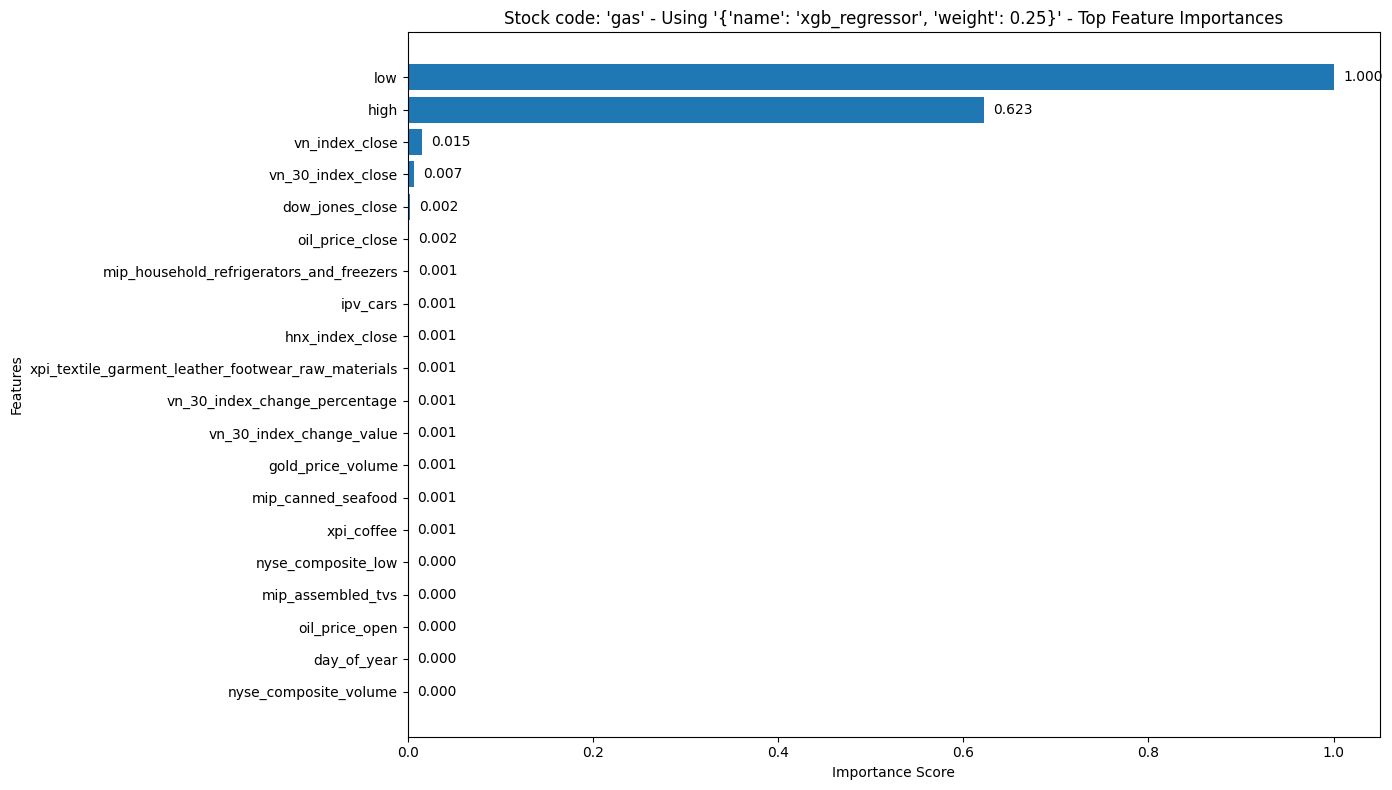

In [21]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

## Feature Selection Type: LASSO

In [22]:
my_feature_selector.get_feature_importance(FeatureSelectorType.LASSO)

,feature,importance
0,high,1.000000
1,open,0.213400
2,low,0.186388
3,vn_30_index_change_value,0.021649
4,mip_fired_tiles,0.002710
...,...,...
216,mip_crude_oil_extraction,0.000000
217,mip_domestic_ceramics,0.000000
218,mip_extracted_stone,0.000000
219,mip_fabric,0.000000


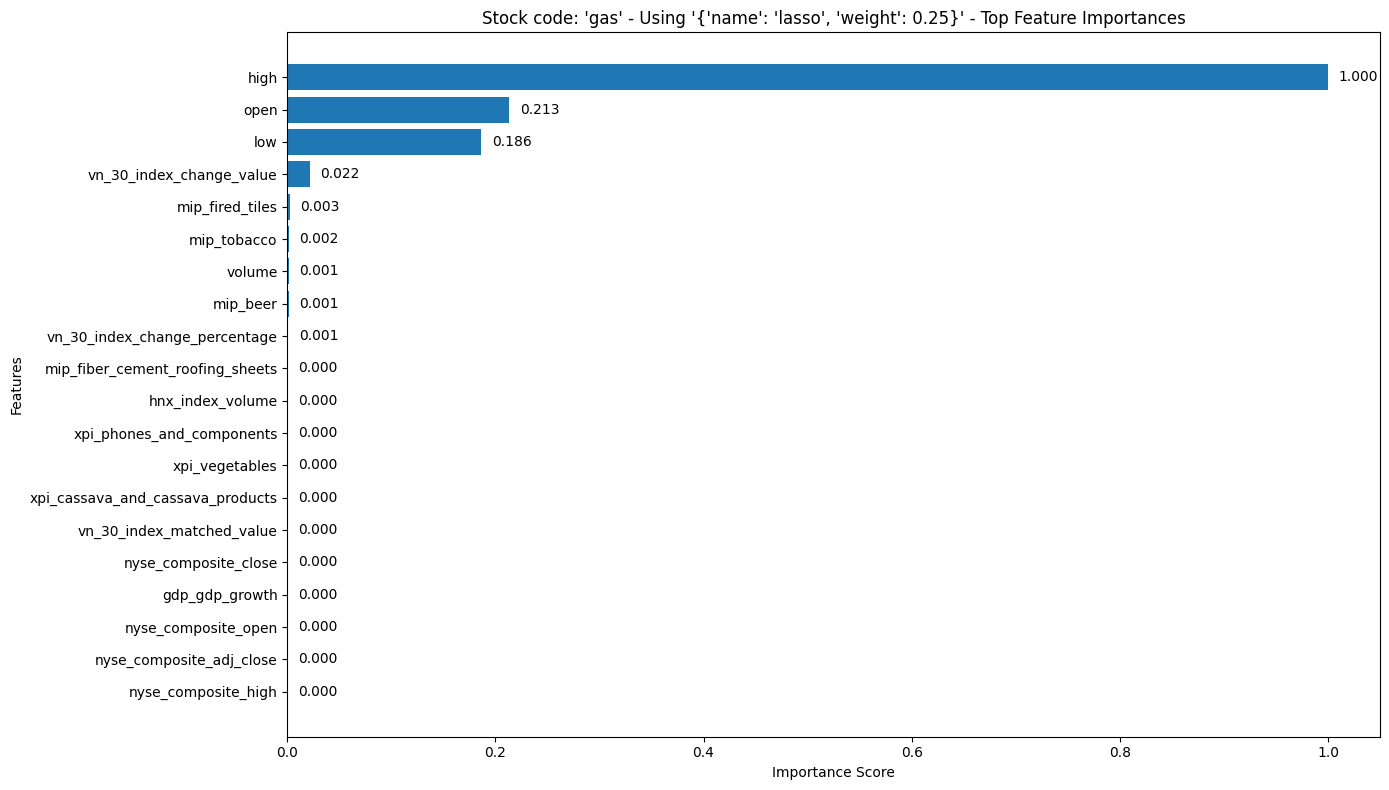

In [23]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.LASSO)

## Feature Selection Type: ELASTIC_NET

In [24]:
my_feature_selector.get_feature_importance(FeatureSelectorType.ELASTIC_NET)

,feature,importance
0,high,1.000000
1,low,0.968282
2,open,0.888127
3,vn_index_close,0.070206
4,mip_canned_seafood,0.060161
...,...,...
216,mip_generated_electricity,0.000000
217,mip_granulated_sugar,0.000000
218,mip_gravel_and_pebbles,0.000000
219,mip_household_electric_fans,0.000000


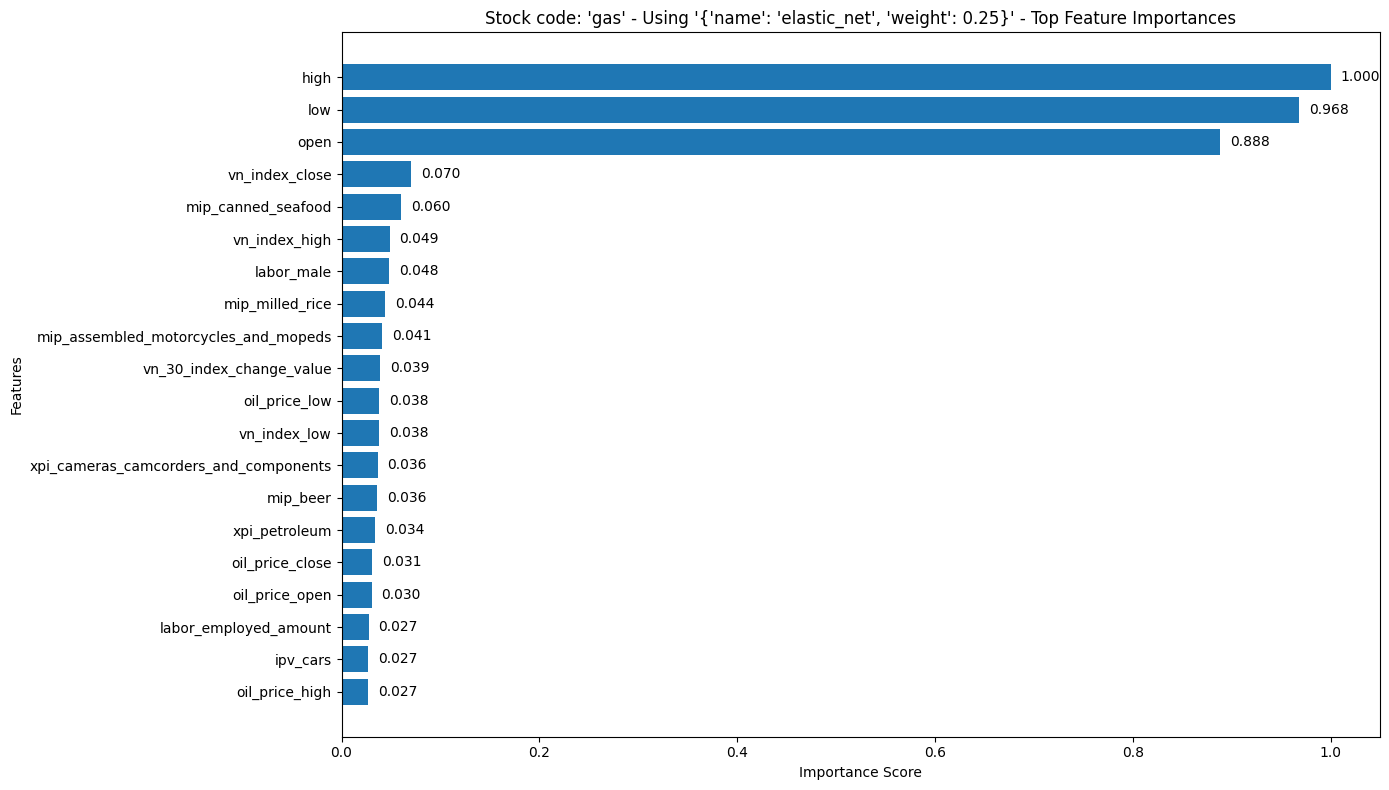

In [25]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.ELASTIC_NET)

## Feature Selection Type: XGB_SHAP

In [26]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_SHAP)

,feature,importance
0,low,1.000000
1,high,0.933494
2,vn_index_close,0.010741
3,vn_30_index_change_percentage,0.009590
4,vn_30_index_change_value,0.008222
...,...,...
216,gold_price_high,0.000000
217,rrrr_refinancing_rate,0.000000
218,rrrr_discount_rate,0.000000
219,treg_international_liquidity_total_reserves_ex...,0.000000


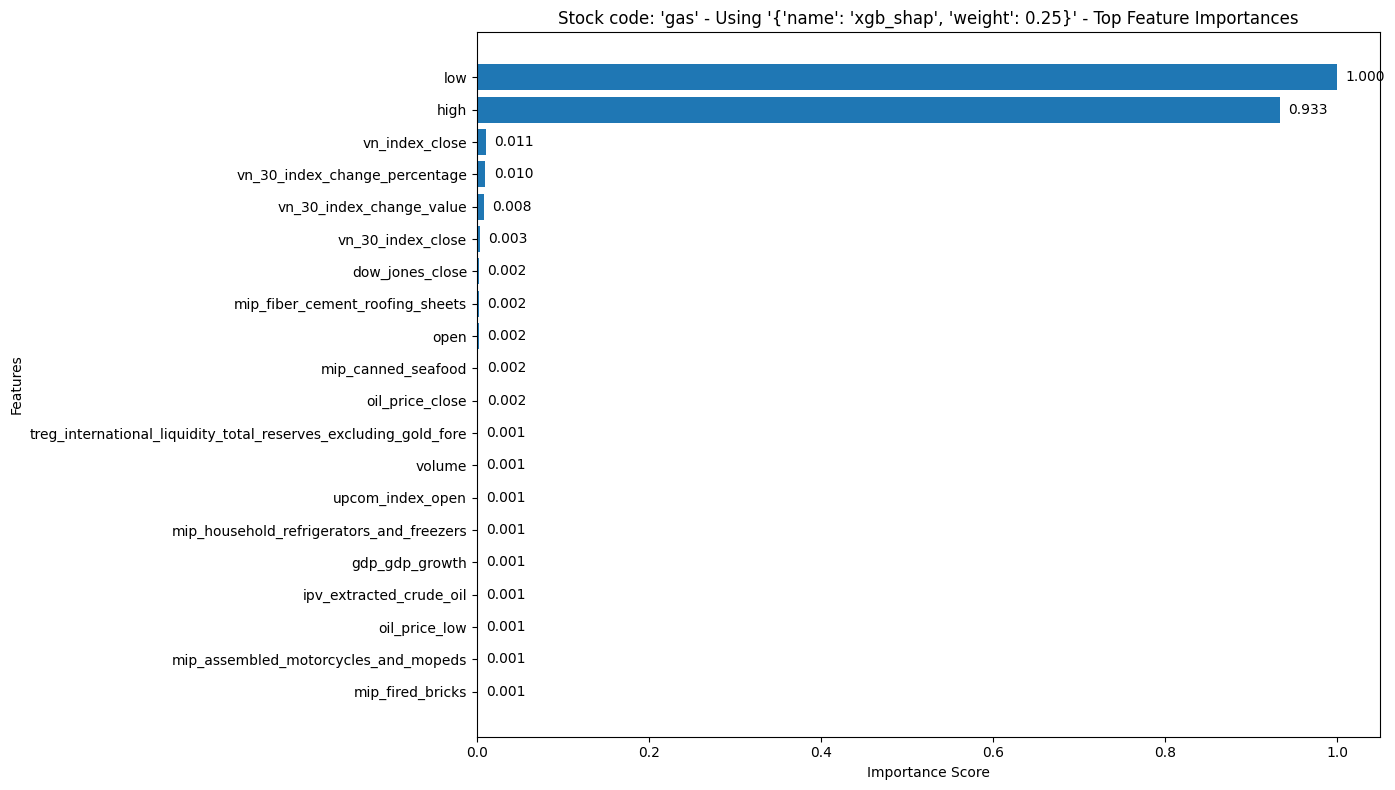

In [27]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_SHAP)

## Summrarize Feature Importance

In [28]:
my_feature_selector.get_feature_importance()

,feature,xgb_regressor,lasso,elastic_net,xgb_shap,xgb_regressor_weighted,lasso_weighted,elastic_net_weighted,xgb_shap_weighted,final_importance
0,high,0.622563,1.000000,1.000000,0.933494,0.155641,0.250000,0.250000,0.233373,0.889014
1,low,1.000000,0.186388,0.968282,1.000000,0.250000,0.046597,0.242071,0.250000,0.788668
2,open,0.000354,0.213400,0.888127,0.002029,0.000088,0.053350,0.222032,0.000507,0.275977
3,vn_index_close,0.015385,0.000000,0.070206,0.010741,0.003846,0.000000,0.017551,0.002685,0.024083
4,vn_30_index_change_value,0.000597,0.021649,0.039023,0.008222,0.000149,0.005412,0.009756,0.002056,0.017373
...,...,...,...,...,...,...,...,...,...,...
216,mip_refined_vegetable_oil,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
217,mip_processed_tea,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
218,mip_printed_newspapers_and_other_printing_prod...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
219,mip_plastic_packaging_and_bags,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


✅ Plot saved to: d:\GIT\master-thesis\logs\feature_selection\gas_final_feature_importances.png


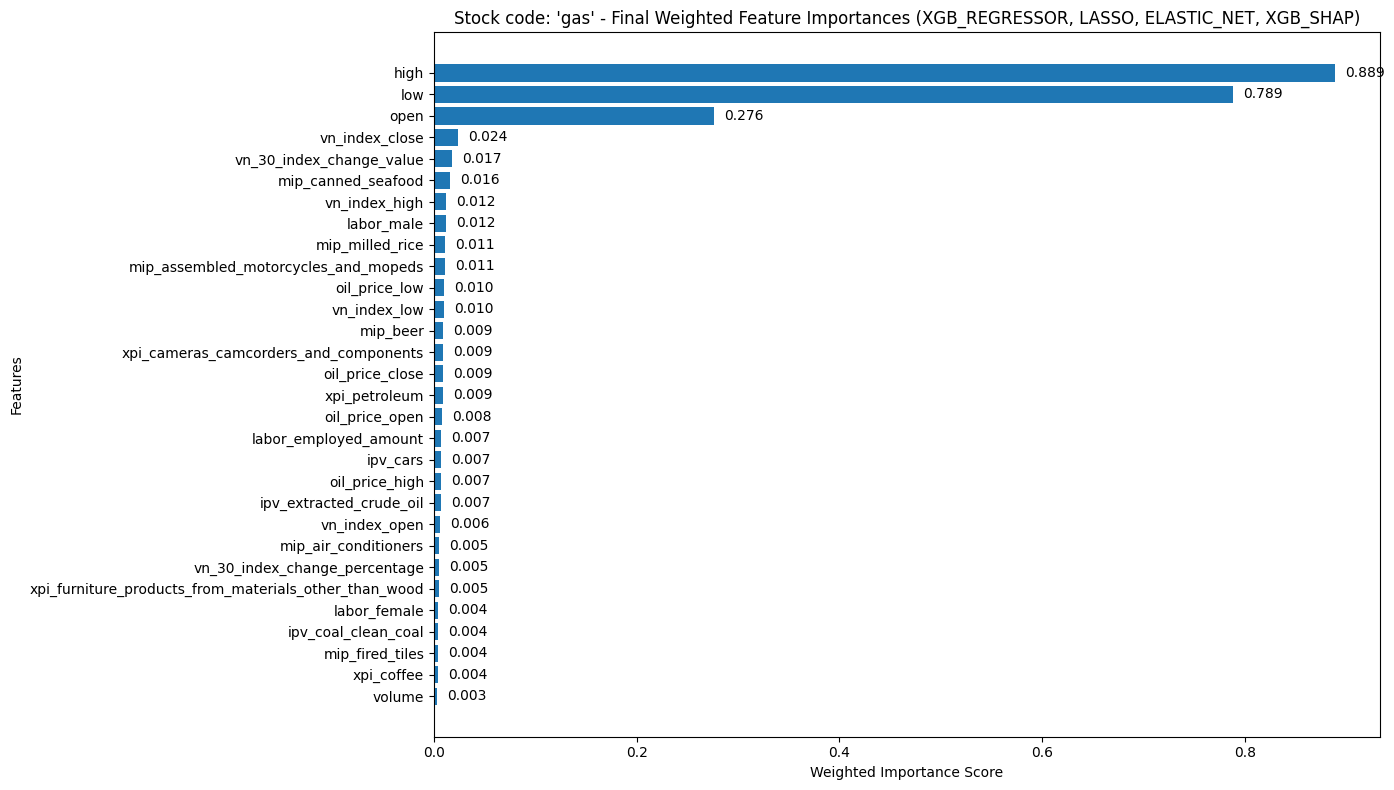

In [29]:
important_features_df = my_feature_selector.plot_final_feature_importances(
    stock_code=stock_code,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [30]:
important_features_df = my_feature_selector.get_important_features_df(
    top_n=TOP_N_FEATURES,
)

In [31]:
important_features_df

,feature,final_importance
21,high,0.889014
49,low,0.788668
131,open,0.275977
168,vn_index_close,0.024083
159,vn_30_index_change_value,0.017373
57,mip_canned_seafood,0.015647
169,vn_index_high,0.012217
46,labor_male,0.012058
81,mip_milled_rice,0.011096
53,mip_assembled_motorcycles_and_mopeds,0.010517


In [32]:
important_features_df.to_csv(f"important_features_df_fs.csv", index=False)

In [33]:
important_features_list = important_features_df["feature"].tolist()
important_features_list

['high',
 'low',
 'open',
 'vn_index_close',
 'vn_30_index_change_value',
 'mip_canned_seafood',
 'vn_index_high',
 'labor_male',
 'mip_milled_rice',
 'mip_assembled_motorcycles_and_mopeds',
 'oil_price_low',
 'vn_index_low',
 'mip_beer',
 'xpi_cameras_camcorders_and_components',
 'oil_price_close',
 'xpi_petroleum',
 'oil_price_open',
 'labor_employed_amount',
 'ipv_cars',
 'oil_price_high',
 'ipv_extracted_crude_oil',
 'vn_index_open',
 'mip_air_conditioners',
 'vn_30_index_change_percentage',
 'xpi_furniture_products_from_materials_other_than_wood',
 'labor_female',
 'ipv_coal_clean_coal',
 'mip_fired_tiles',
 'xpi_coffee',
 'volume',
 'xpi_pepper',
 'ipv_processed_seafood',
 'vn_30_index_close',
 'xpi_cassava_and_cassava_products',
 'mip_light_bulbs',
 'upcom_index_high',
 'rrrr_refinancing_rate',
 'dow_jones_close',
 'ipv_mononatri_glutamat',
 'month_cos']

## Heatmap Visualization

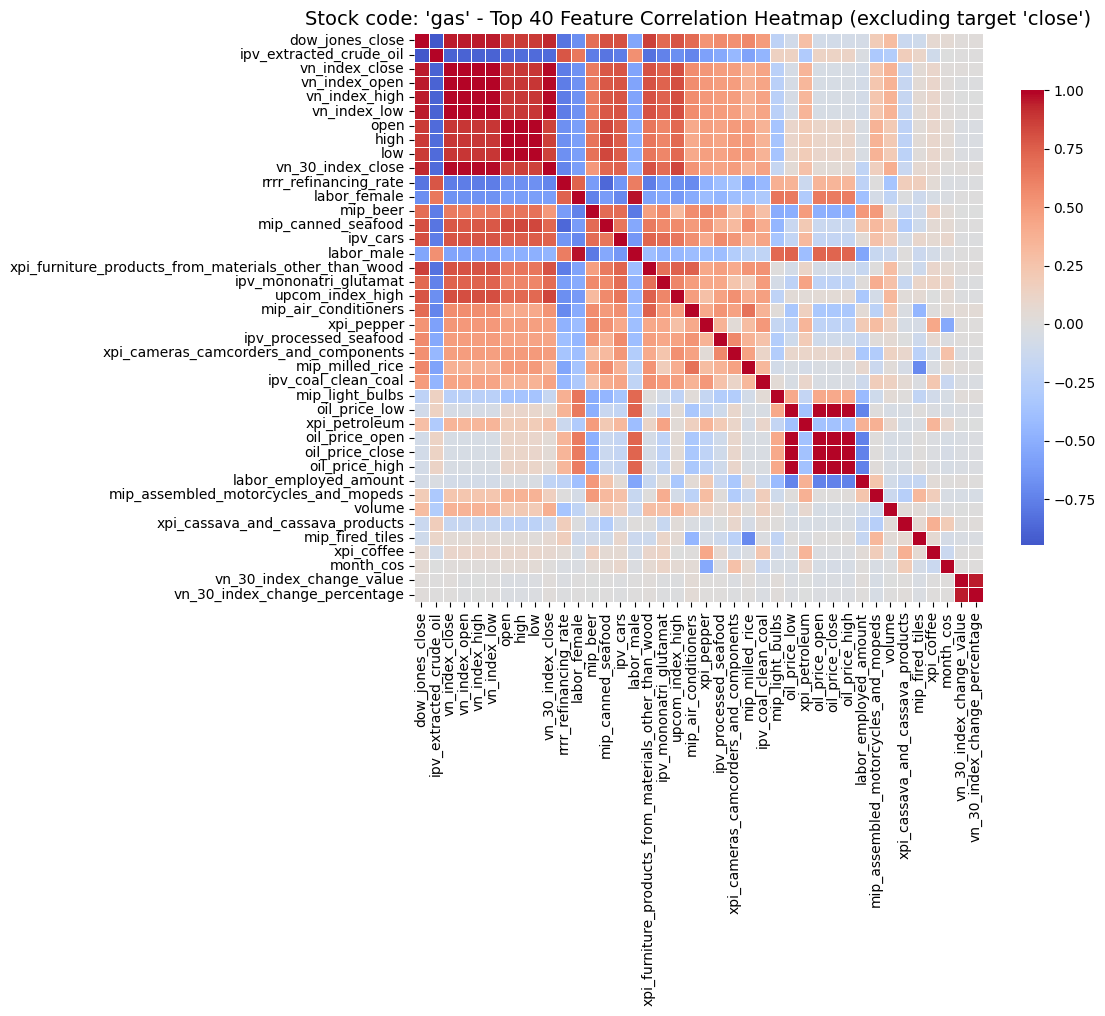

In [34]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Correlation DataFrame

In [35]:
correlation_df = my_feature_selector.get_feature_correlation_df(
    important_features_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

In [36]:
correlation_df

,feature_1,feature_2,corr
0,vn_index_open,vn_index_high,0.999817
1,vn_index_close,vn_index_low,0.999730
2,vn_index_close,vn_index_high,0.999707
3,vn_index_open,vn_index_low,0.999699
4,vn_index_high,vn_index_low,0.999617
5,vn_index_close,vn_index_open,0.999449
6,open,low,0.999335
7,open,high,0.999255
8,oil_price_low,oil_price_close,0.999254
9,oil_price_open,oil_price_high,0.999170


In [37]:
kept_features, dropped_features, pruned_importance_df = (
    my_feature_selector.drop_low_importance_correlated_features(
        important_features_df=important_features_df,
        correlation_df=correlation_df,
        corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
    )
)

🔍 Dropped 14 highly correlated features (|r| >= 0.85):
['dow_jones_close', 'labor_female', 'low', 'oil_price_close', 'oil_price_high', 'oil_price_open', 'open', 'rrrr_refinancing_rate', 'vn_30_index_change_percentage', 'vn_30_index_close', 'vn_index_close', 'vn_index_high', 'vn_index_low', 'vn_index_open']
✅ Kept 26 features after pruning correlation redundancy.


In [38]:
kept_features

['high',
 'vn_30_index_change_value',
 'mip_canned_seafood',
 'labor_male',
 'mip_milled_rice',
 'mip_assembled_motorcycles_and_mopeds',
 'oil_price_low',
 'mip_beer',
 'xpi_cameras_camcorders_and_components',
 'xpi_petroleum',
 'labor_employed_amount',
 'ipv_cars',
 'ipv_extracted_crude_oil',
 'mip_air_conditioners',
 'xpi_furniture_products_from_materials_other_than_wood',
 'ipv_coal_clean_coal',
 'mip_fired_tiles',
 'xpi_coffee',
 'volume',
 'xpi_pepper',
 'ipv_processed_seafood',
 'xpi_cassava_and_cassava_products',
 'mip_light_bulbs',
 'upcom_index_high',
 'ipv_mononatri_glutamat',
 'month_cos']

In [39]:
dropped_features

['dow_jones_close',
 'labor_female',
 'low',
 'oil_price_close',
 'oil_price_high',
 'oil_price_open',
 'open',
 'rrrr_refinancing_rate',
 'vn_30_index_change_percentage',
 'vn_30_index_close',
 'vn_index_close',
 'vn_index_high',
 'vn_index_low',
 'vn_index_open']

## Number of features dropped

In [40]:
print(f"Dropped: {len(dropped_features)} features")

Dropped: 14 features


In [41]:
feature_selected_train = train.drop(columns=dropped_features)
feature_selected_train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,0,3,1,2,0.500000,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,0,4,1,2,0.500000,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,0,4,1,2,0.500000,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,0,4,1,2,0.500000,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,0,4,1,2,0.500000,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.335604,92.267406,717.586207,879.310345,67.931034,572.413793,255.862069,237.241379,2917.241379,206.551724,...,0,1,1,1,0.866025,0.500000,-0.433884,-0.900969,0.538005,0.842942
2936,5.827473,93.140323,684.094000,720.000000,59.000000,310.000000,336.000000,250.000000,2760.000000,308.000000,...,0,2,1,2,0.866025,-0.500000,-0.433884,-0.900969,0.979614,-0.200891
2937,6.300659,92.304816,698.965517,848.275862,64.827586,531.034483,249.655172,233.103448,2793.103448,201.379310,...,0,1,1,1,0.866025,0.500000,0.000000,1.000000,0.580800,0.814046
2938,6.289011,92.317287,692.758621,837.931034,63.793103,517.241379,247.586207,231.724138,2751.724138,199.655172,...,0,1,1,1,0.866025,0.500000,0.781831,0.623490,0.594727,0.803928


## Heatmap Visualization before + after feature selection

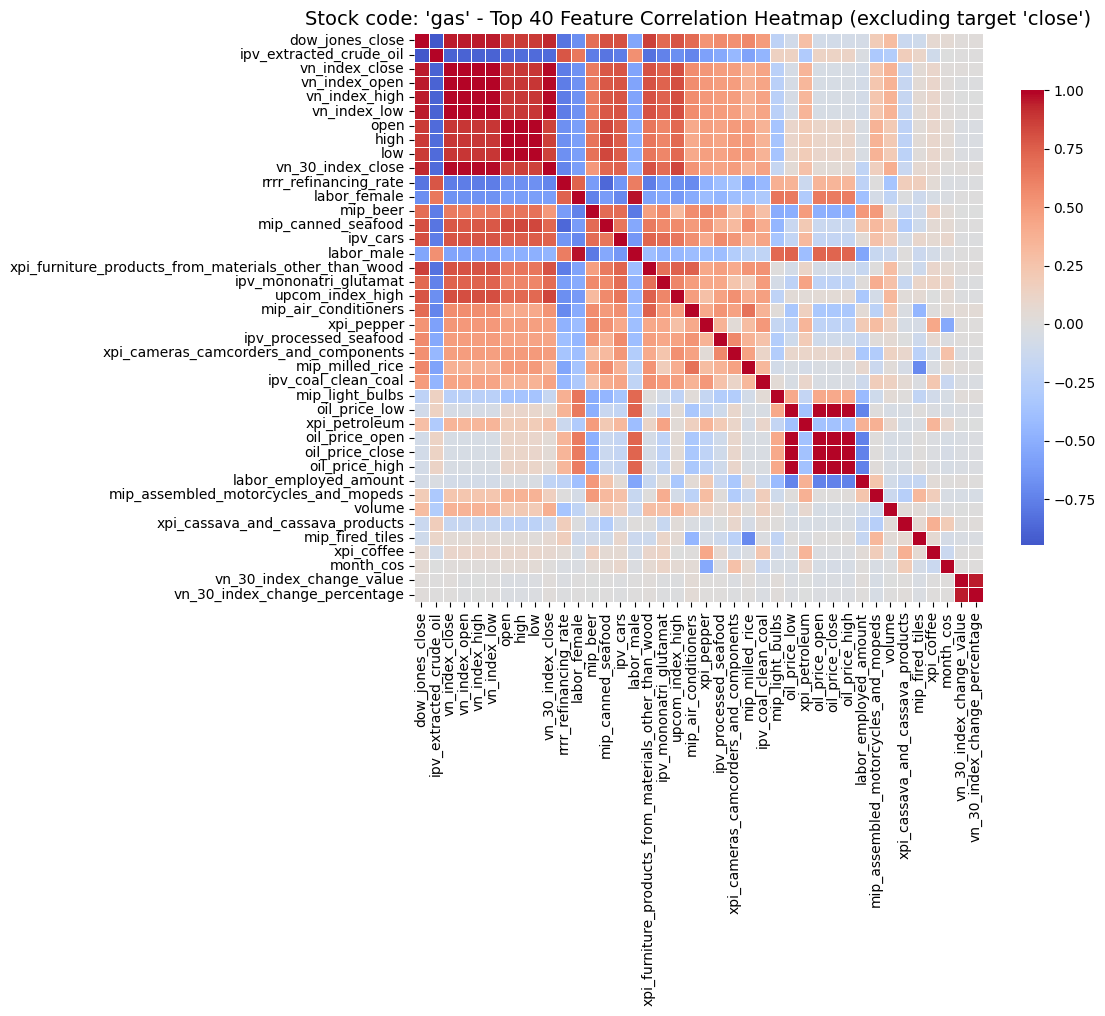

In [42]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

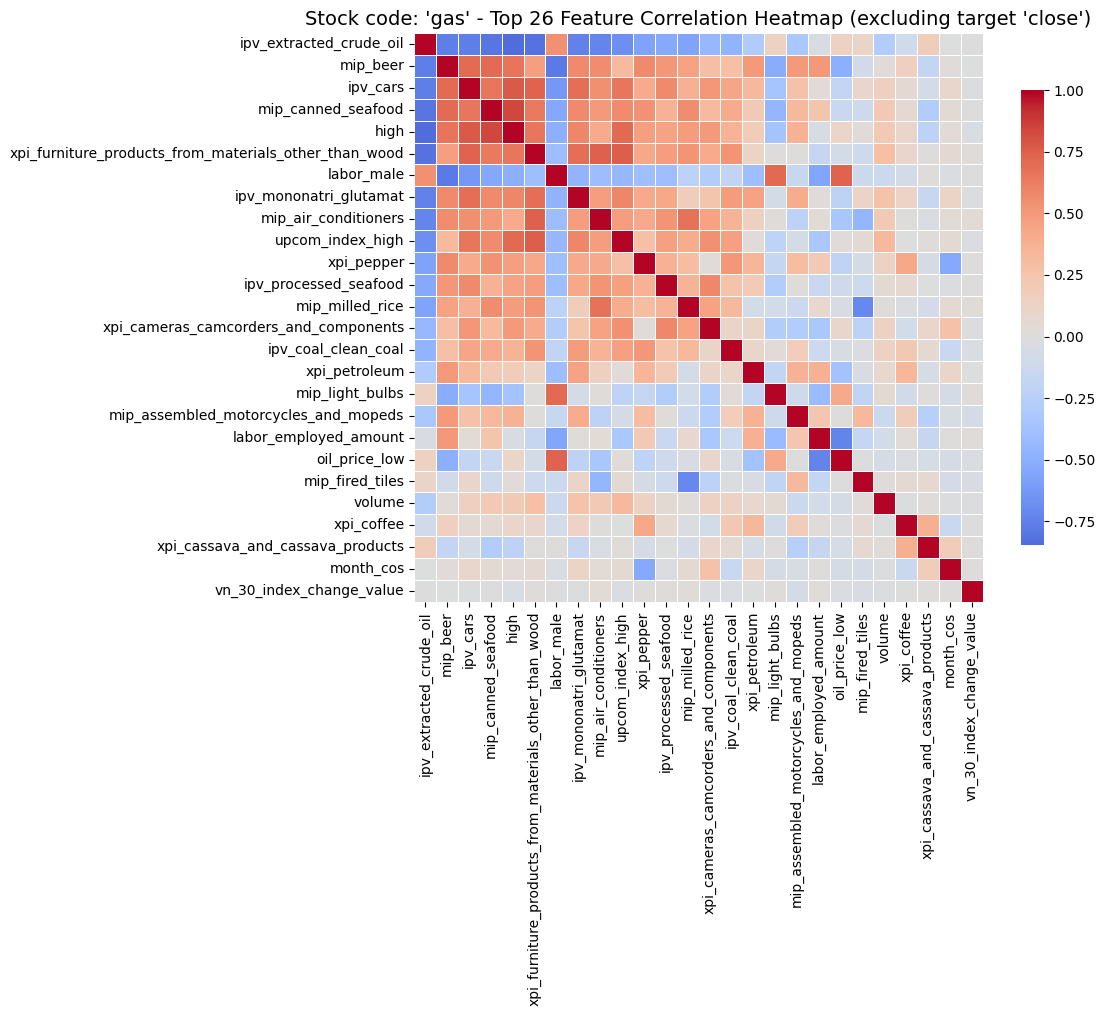

In [43]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=kept_features,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Feature Selected train dataframe

In [44]:
feature_selected_train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,0,3,1,2,0.500000,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,0,4,1,2,0.500000,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,0,4,1,2,0.500000,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,0,4,1,2,0.500000,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,0,4,1,2,0.500000,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.335604,92.267406,717.586207,879.310345,67.931034,572.413793,255.862069,237.241379,2917.241379,206.551724,...,0,1,1,1,0.866025,0.500000,-0.433884,-0.900969,0.538005,0.842942
2936,5.827473,93.140323,684.094000,720.000000,59.000000,310.000000,336.000000,250.000000,2760.000000,308.000000,...,0,2,1,2,0.866025,-0.500000,-0.433884,-0.900969,0.979614,-0.200891
2937,6.300659,92.304816,698.965517,848.275862,64.827586,531.034483,249.655172,233.103448,2793.103448,201.379310,...,0,1,1,1,0.866025,0.500000,0.000000,1.000000,0.580800,0.814046
2938,6.289011,92.317287,692.758621,837.931034,63.793103,517.241379,247.586207,231.724138,2751.724138,199.655172,...,0,1,1,1,0.866025,0.500000,0.781831,0.623490,0.594727,0.803928
